<a href="https://colab.research.google.com/github/22f1001966/22f1001966_my_new_repository/blob/main/Copy_of_26T2_Day6_Feature_Engineering_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Day 6: Feature Engineering Hands-On Session

Objective: Transform raw, messy web analytics data into a mathematically robust matrix ready for Machine Learning models.

We will progress through 5 phases:

* Data Cleansing & Normalization

* Temporal Engineering

* Feature Creation & Advanced Encoding

* Target Variable Setup

* The Scikit-Learn Preprocessing Pipeline

In [298]:
# importing all the necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

#### Phase 1: Cleansing & Normalization

Algorithms cannot understand strings like `"not available in demo dataset"`. If we leave these in, the model will treat them as a highly predictive category rather than missing data. We also need to drop columns that offer absolutely no variance.

In [299]:
# 1. Load the Dataset
# Load the dataset (Make sure train_data.csv is uploaded to your Colab environment)
train_url = "https://drive.google.com/file/d/1UCtt9r-jWXo3QbX4m7nA3tKuK-eGbjOE/view?usp=sharing"
test_url = "https://drive.google.com/file/d/1DC_r07Pgm9arUdHtsJTpSQNyzxe2hj3m/view?usp=drive_link"

train_data = "https://drive.google.com/uc?export=download&id=1UCtt9r-jWXo3QbX4m7nA3tKuK-eGbjOE"
test_data = "https://drive.google.com/uc?export=download&id=1DC_r07Pgm9arUdHtsJTpSQNyzxe2hj3m"

df = pd.read_csv(train_data, low_memory=False)
print(f"Initial Dataset Shape: {df.shape}")
df.head()


Initial Dataset Shape: (116023, 52)


,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,66,not available in demo dataset,1475804633,Americas,False,1.0


In [300]:
# Replace specific nulls with standard np.nan
null_strings = ['not available in demo dataset', 'not available', '(not set)', 'unknown.unknown']
df.replace(null_strings, np.nan, inplace=True)

df.head()

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,NaN,NaN,NaN,medium,Region_2,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1500100799,Americas,False,1.0
1,True,0.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,1,NaN,1495262065,Americas,False,1.0
2,True,0.0,Chrome,NaN,NaN,(not provided),medium,Region_2,NaN,NaN,...,NaN,desktop,Organic Search,NaN,6,NaN,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,NaN,NaN,NaN,medium,Region_4,NaN,NaN,...,NaN,desktop,Social,NaN,1,NaN,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,NaN,NaN,NaN,medium,Region_3,NaN,NaN,...,NaN,desktop,Direct,NaN,66,NaN,1475804633,Americas,False,1.0


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116022 non-null  object 
 3   device.screenResolution                       0 non-null       float64
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   0 

In [302]:
df.dtypes

,0
trafficSource.isTrueDirect,object
purchaseValue,float64
browser,object
device.screenResolution,float64
trafficSource.adContent,object
trafficSource.keyword,object
screenSize,object
geoCluster,object
trafficSource.adwordsClickInfo.slot,object
device.mobileDeviceBranding,float64


In [303]:
df.dtypes.value_counts()

,count
object,24
float64,18
int64,9
bool,1


In [304]:
#number - int or float type column list
df.select_dtypes(include="number").columns

Index(['purchaseValue', 'device.screenResolution',
       'device.mobileDeviceBranding', 'device.mobileInputSelector', 'userId',
       'device.mobileDeviceMarketingName', 'gclIdPresent',
       'device.operatingSystemVersion', 'sessionNumber', 'device.flashVersion',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId',
       'browserMajor', 'device.browserSize',
       'trafficSource.adwordsClickInfo.page', 'pageViews', 'locationZone',
       'device.mobileDeviceModel', 'totals.bounces', 'date', 'device.language',
       'device.browserVersion', 'totalHits', 'device.screenColors',
       'sessionStart', 'new_visits'],
      dtype='object')

In [305]:
#object or categorical columns
df.select_dtypes(include='object').columns

Index(['trafficSource.isTrueDirect', 'browser', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'trafficSource.campaign',
       'geoNetwork.networkDomain', 'geoNetwork.region', 'trafficSource', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'locationCountry',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'geoNetwork.metro', 'trafficSource.referralPath',
       'deviceType', 'userChannel', 'geoNetwork.continent'],
      dtype='object')

In [306]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

,0
device.screenResolution,116023
device.operatingSystemVersion,116023
device.mobileDeviceBranding,116023
device.mobileInputSelector,116023
device.flashVersion,116023
device.mobileDeviceMarketingName,116023
device.screenColors,116023
device.browserVersion,116023
device.mobileDeviceModel,116023
device.browserSize,116023


In [307]:
missing[missing>0]

,0
device.screenResolution,116023
device.operatingSystemVersion,116023
device.mobileDeviceBranding,116023
device.mobileInputSelector,116023
device.flashVersion,116023
device.mobileDeviceMarketingName,116023
device.screenColors,116023
device.browserVersion,116023
device.mobileDeviceModel,116023
device.browserSize,116023


In [308]:
missing[missing>0].value_counts().sum()

np.int64(35)

#### EDA & Visualizing Skewness (Section 2)
Before engineering features, we need to understand the distribution of our target variable and key numerical features.

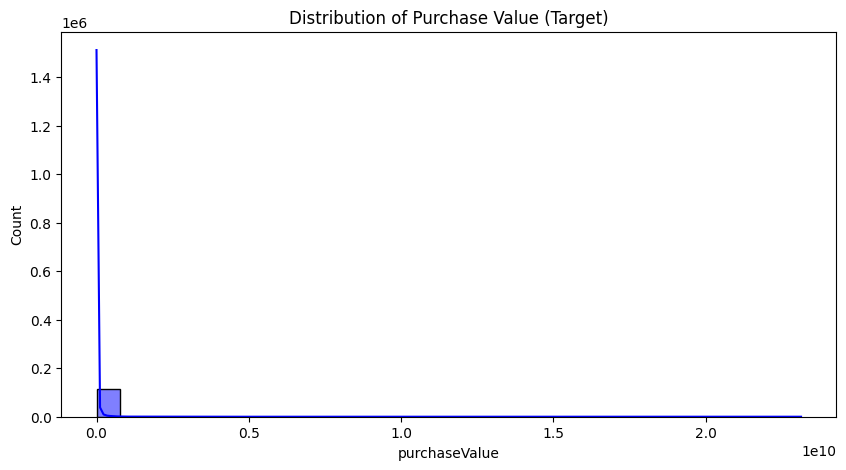

In [309]:
# Convert numerical columns to float for analysis
num_cols = ['totalHits', 'pageViews', 'purchaseValue']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

plt.figure(figsize=(10, 5))
sns.histplot(df['purchaseValue'], bins=30, kde=True, color='blue')
plt.title('Distribution of Purchase Value (Target)')
plt.show()

<Axes: xlabel='purchaseValue', ylabel='Count'>

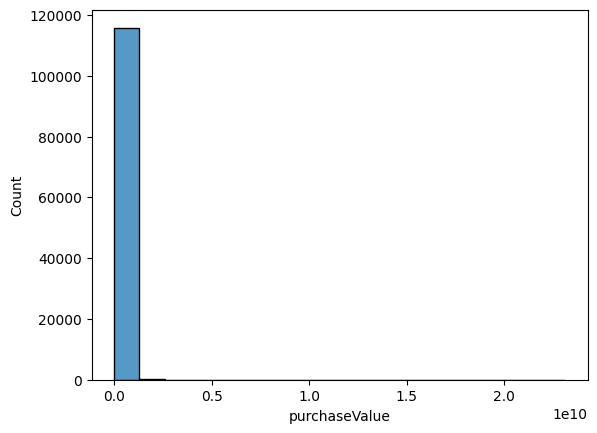

In [310]:
sns.histplot(df["purchaseValue"])

<Axes: xlabel='purchaseValue', ylabel='Count'>

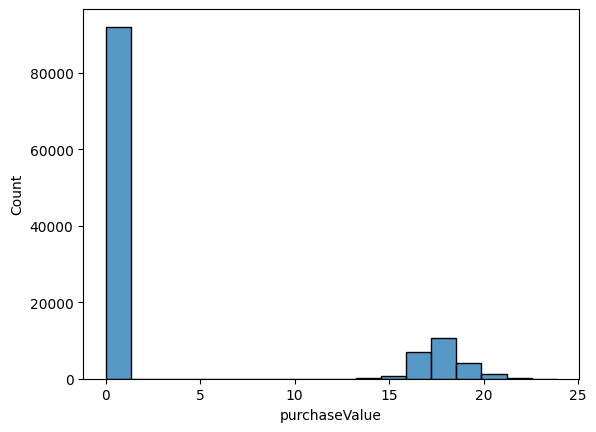

In [311]:
sns.histplot(np.log1p(df["purchaseValue"]))

<Axes: >

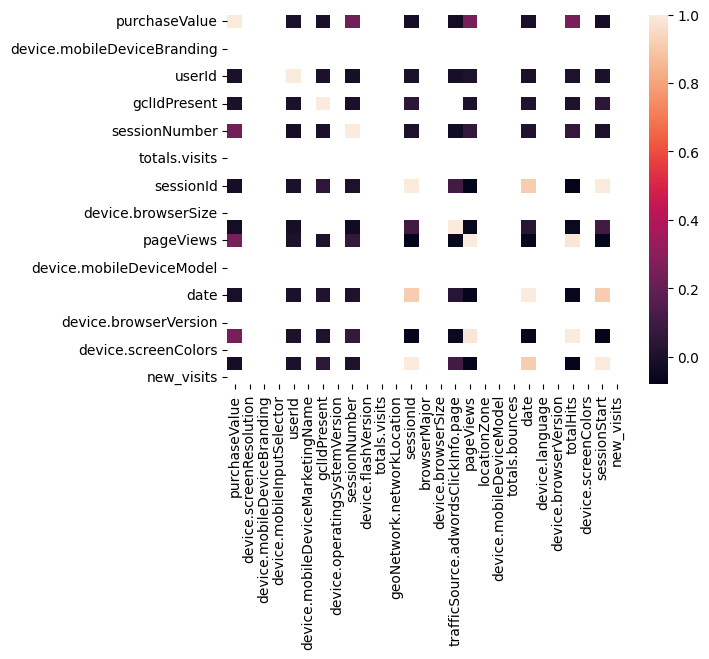

In [312]:
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr)

In [313]:
# Step 1: Standardize Null Representations
bad_strings = [
    'not available in demo dataset',
    '(not provided)',
    '(not set)',
    'unknown.unknown',
    'Not Socially Engaged'
]
df.replace(bad_strings, np.nan, inplace=True)

# Step 2: Drop Zero-Variance Features
# If every row has the same value, it gives the model zero predictive power.
nunique = df.nunique(dropna=False)
cols_to_drop = nunique[nunique == 1].index
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with zero variance.")
print(f"List of dropped columns: {cols_to_drop.tolist()}")

# Step 3: Smart Imputation (Domain-Logic based)
# If a bounce isn't recorded, it likely means they didn't bounce (0).
# If pageViews is missing, we fill it with the median.
df['totals.bounces'] = df['totals.bounces'].fillna(0)
df['pageViews'] = pd.to_numeric(df['pageViews'], errors='coerce')
df['totalHits'] = pd.to_numeric(df['totalHits'], errors='coerce')
df['pageViews'] = df['pageViews'].fillna(df['pageViews'].median())

Dropped 17 columns with zero variance.
List of dropped columns: ['device.screenResolution', 'screenSize', 'device.mobileDeviceBranding', 'device.mobileInputSelector', 'device.mobileDeviceMarketingName', 'device.operatingSystemVersion', 'device.flashVersion', 'totals.visits', 'geoNetwork.networkLocation', 'browserMajor', 'device.browserSize', 'socialEngagementType', 'locationZone', 'device.mobileDeviceModel', 'device.language', 'device.browserVersion', 'device.screenColors']


In [314]:
df['purchaseValue'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 116023 entries, 0 to 116022
Series name: purchaseValue
Non-Null Count   Dtype  
--------------   -----  
116023 non-null  float64
dtypes: float64(1)
memory usage: 906.6 KB


In [315]:
#cardinality of categorical or object datatype columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, df[col].nunique())

trafficSource.isTrueDirect 1
browser 33
trafficSource.adContent 53
trafficSource.keyword 565
geoCluster 5
trafficSource.adwordsClickInfo.slot 3
trafficSource.campaign 27
geoNetwork.networkDomain 3
geoNetwork.region 386
trafficSource 160
os 17
geoNetwork.subContinent 22
trafficSource.medium 6
trafficSource.adwordsClickInfo.isVideoAd 1
locationCountry 192
trafficSource.adwordsClickInfo.adNetworkType 2
geoNetwork.city 693
geoNetwork.metro 102
trafficSource.referralPath 941
deviceType 3
userChannel 8
geoNetwork.continent 5


#### 1. Date & Time Feature Engineering (Section 3)
Our `date` column is currently an `integer (e.g., 20171002)`. A linear model just sees this as a massive number, not a point in time. We need to engineer it.

Extracting temporal patterns from the raw `date` (YYYYMMDD) and `sessionStart` (Unix Timestamp).

In [316]:
# Convert raw string date to datetime object
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Extract features from Date
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['DayOfWeek'] = df['date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Convert Unix timestamp to datetime and extract time features
df['sessionStart'] = pd.to_datetime(df['sessionStart'].astype(int), unit='s')
df['SessionHour'] = df['sessionStart'].dt.hour

# Drop the original raw datetime columns
df.drop(['date', 'sessionStart'], axis=1, inplace=True)
print(df[['Year', 'Month', 'DayOfWeek', 'IsWeekend', 'SessionHour']].head())

   Year  Month  DayOfWeek  IsWeekend  SessionHour
0  2017      7          4          0            6
1  2017      5          4          0            6
2  2017     10          4          0           14
3  2017      1          1          0            8
4  2016     10          3          0            1


In [317]:
df.select_dtypes(include='number').head()

,purchaseValue,userId,gclIdPresent,sessionNumber,sessionId,trafficSource.adwordsClickInfo.page,pageViews,totals.bounces,totalHits,new_visits,Year,Month,Day,DayOfWeek,IsWeekend,SessionHour
0,0.0,61421,0,1,1500100799,NaN,1.0,1.0,1,1.0,2017,7,14,4,0,6
1,0.0,72287,0,1,1495262065,NaN,1.0,1.0,1,1.0,2017,5,19,4,0,6
2,0.0,25180,0,2,1508510328,NaN,6.0,0.0,6,NaN,2017,10,20,4,0,14
3,0.0,41295,0,1,1483431838,NaN,1.0,1.0,1,1.0,2017,1,3,1,0,8
4,88950000.0,113697,0,1,1475804633,NaN,54.0,0.0,66,1.0,2016,10,6,3,0,1


In [318]:
df.select_dtypes(include='datetime').columns.tolist()

[]

In [319]:
# # missing = df.isna().mean()*100
# missing
missing_percent = df.isna().mean()*100
missing_percent

,0
trafficSource.isTrueDirect,63.033192
purchaseValue,0.000000
browser,0.000862
trafficSource.adContent,97.446196
trafficSource.keyword,95.607767
geoCluster,0.000000
trafficSource.adwordsClickInfo.slot,96.310214
userId,0.000000
trafficSource.campaign,95.050119
geoNetwork.networkDomain,0.000000


#### 2. Numerical Feature Engineering (Section 4)
Creating new interaction metrics and transforming skewed distributions.

In [320]:
# Ensure visits is numeric
# Determine base values for calculations, assuming 1 if column was dropped due to zero variance
visits_val = 1
if 'totals.visits' in df.columns:
    df['totals.visits'] = pd.to_numeric(df['totals.visits'], errors='coerce').fillna(1)
    visits_val = df['totals.visits']

total_hits_base = 1
if 'totalHits' in df.columns:
    total_hits_base = df['totalHits']

page_views_base = 1
if 'pageViews' in df.columns:
    page_views_base = df['pageViews']

# Create new feature: Hits per Visit
df['HitsPerVisit'] = total_hits_base / visits_val

# Create new feature: PageViews per Visit
df['PageViewsPerVisit'] = page_views_base / visits_val

# Log Transformation for highly skewed features
df['log_totalHits'] = np.log1p(total_hits_base) # log1p handles 0 values safely

# Scaling numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['HitsPerVisit', 'PageViewsPerVisit', 'log_totalHits']])
df[['HitsPerVisit_scaled', 'PageViewsPerVisit_scaled', 'log_totalHits_scaled']] = scaled_features

print(df[['HitsPerVisit_scaled', 'PageViewsPerVisit_scaled', 'log_totalHits_scaled']].head())

   HitsPerVisit_scaled  PageViewsPerVisit_scaled  log_totalHits_scaled
0            -0.489436                 -0.516696             -0.872092
1            -0.489436                 -0.516696             -0.872092
2            -0.234717                 -0.168132              0.233960
3            -0.489436                 -0.516696             -0.872092
4             2.821908                  3.178087              2.228216


#### 3. Boolean Feature Engineering (Section 5)
Mapping TRUE/FALSE and 1/0 strings to standard integer formats.

In [321]:
boolean_columns = ['device.isMobile', 'new_visits', 'gclIdPresent']

for col in boolean_columns:
    # Fill NAs with 0 and convert to integer
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(df[boolean_columns].head())

   device.isMobile  new_visits  gclIdPresent
0                0           1             0
1                0           1             0
2                0           0             0
3                0           1             0
4                0           1             0


#### 4. Categorical Feature Engineering (Section 6)
Handling low cardinality nominal data via One-Hot Encoding and high cardinality data via Frequency Encoding.

In [322]:
# 1. Low Cardinality: One-Hot Encoding for 'browser', 'os', 'deviceType'
df = pd.get_dummies(df, columns=['browser', 'os', 'deviceType'], drop_first=True)

# 2. High Cardinality: Frequency Encoding for 'geoNetwork.city'
city_freq = df['geoNetwork.city'].value_counts().to_dict()
df['City_Freq_Encoded'] = df['geoNetwork.city'].map(city_freq).fillna(0)
df.drop('geoNetwork.city', axis=1, inplace=True)

print(df.columns)

Index(['trafficSource.isTrueDirect', 'purchaseValue',
       'trafficSource.adContent', 'trafficSource.keyword', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'userId',
       'trafficSource.campaign', 'geoNetwork.networkDomain', 'gclIdPresent',
       'sessionNumber', 'geoNetwork.region', 'trafficSource', 'sessionId',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'locationCountry',
       'trafficSource.adwordsClickInfo.adNetworkType',
       'trafficSource.adwordsClickInfo.page', 'geoNetwork.metro', 'pageViews',
       'trafficSource.referralPath', 'totals.bounces', 'userChannel',
       'totalHits', 'geoNetwork.continent', 'device.isMobile', 'new_visits',
       'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'SessionHour',
       'HitsPerVisit', 'PageViewsPerVisit', 'log_totalHits',
       'HitsPerVisit_scaled', 'PageViewsPerVisit_scaled',
       'log_totalHits_scaled', 'browser_Amazon Silk',
       'bro

#### 5. Text Feature Engineering (Section 7)
Converting unstructured text (`trafficSource.referralPath`) into numerical vectors using TF-IDF.

In [323]:
# Fill missing text with empty string
df['trafficSource.referralPath'] = df['trafficSource.referralPath'].fillna('')

# Initialize TF-IDF (limiting features to avoid exploding dimensions)
tfidf = TfidfVectorizer(max_features=10)
text_vectors = tfidf.fit_transform(df['trafficSource.referralPath']).toarray()

# Create dataframe of text features and concatenate
text_df = pd.DataFrame(text_vectors, columns=[f'referral_tfidf_{i}' for i in range(text_vectors.shape[1])])
df = pd.concat([df.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)

# Drop original text column
df.drop('trafficSource.referralPath', axis=1, inplace=True)

#### 6. Feature Selection (Section 8)
Removing unique identifiers and redundant features to prevent overfitting.

In [324]:
# Removing IDs and redundant unscaled features
columns_to_drop = [
    'sessionId',
    'userId',
    'totalHits',
    'pageViews',
    'totals.visits',
    'HitsPerVisit',
    'PageViewsPerVisit',
    'log_totalHits'
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)

print(f"Final model-ready dataset shape: {df.shape}")

Final model-ready dataset shape: (116023, 94)


#### 7. Model Building & Evaluation (Section 9)
Training advanced tree-based ensemble models on our newly engineered features.

In [325]:
from sklearn.preprocessing import LabelEncoder

# 1. Identify all remaining text/categorical columns in your dataset
object_columns = df.select_dtypes(include=['object', 'string']).columns

print(f"Encoding {len(object_columns)} remaining text columns...")

# 2. Apply Label Encoding to convert them to numbers
le = LabelEncoder()
for col in object_columns:
    # Convert to string first to handle any mixed data types or hidden NaNs safely
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Check if there are any non-numeric columns left (should return empty)
print("Remaining non-numeric columns:", df.select_dtypes(include=['object']).columns.tolist())

Encoding 17 remaining text columns...
Remaining non-numeric columns: []


In [326]:
# Define features (X) and target (y)
X = df.drop('purchaseValue', axis=1)
y = df['purchaseValue']

# Train/Test Split (Note: We use a small test size here due to the sample data size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Models
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"MSE: {mse:.2f}")
    # R2 is often NA or inaccurate on extremely small sample sets,
    # but works perfectly on the full dataset.
    print(f"R-squared: {r2:.2f}\n")

--- Random Forest ---
MSE: 36499738827276912.00
R-squared: 0.23

--- XGBoost ---
MSE: 40716034046055528.00
R-squared: 0.14

--- LightGBM ---
MSE: 36704523449389960.00
R-squared: 0.22

